Augur pertabation analysis comparing IPF severe vs control and IPF mild vs control at level_2. This generated the figure 5a.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import seaborn as sns
from pathlib import Path
import re

plt.rcParams['pdf.fonttype'] = 42

/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
plot_folder = "/media/synology/Huijuan/Plots/IPF_subsets/IPF_paper/"

In [3]:
augur_mild = pd.read_csv("/media/synology/Huijuan/Plots/IPF_subsets/snRNA_IPF_control_mild_augur_scores_level2_all.txt", sep="\t")
augur_severe = pd.read_csv("/media/synology/Huijuan/Plots/IPF_subsets/snRNA_IPF_control_severe_augur_scores_level2_all.txt", sep="\t")

augur_mild = augur_mild.rename(columns={'Unnamed: 0': 'cell_type'})
augur_severe = augur_severe.rename(columns={'Unnamed: 0': 'cell_type'})

In [4]:
# Build a wide Augur table (one row per cell type, mild + severe columns)
aug_m = augur_mild[["cell_type", "mean_augur_score"]].rename(columns={"mean_augur_score": "mean_augur_score_mild"})
aug_s = augur_severe[["cell_type", "mean_augur_score"]].rename(columns={"mean_augur_score": "mean_augur_score_severe"})

df = aug_m.merge(aug_s, on="cell_type", how="inner")   # inner = keep only cell types present in both
df = df.dropna(subset=["mean_augur_score_mild", "mean_augur_score_severe"])
df = df.sort_values("mean_augur_score_mild", ascending=True).reset_index(drop=True)

df

,cell_type,mean_augur_score_mild,mean_augur_score_severe
0,Macrophages,0.564893,0.664266
1,Lymphatic EC,0.609177,0.665666
2,Airway epithelium,0.626251,0.586001
3,Dendritic cells,0.637021,0.579465
4,Fibroblast lineage,0.645191,0.761738
5,Alveolar epithelium,0.658163,0.744198
6,EC arterial,0.669935,0.768274
7,Smooth muscle,0.672602,0.647359
8,Monocytes,0.708450,0.685374
9,T cell lineage,0.711585,0.749066


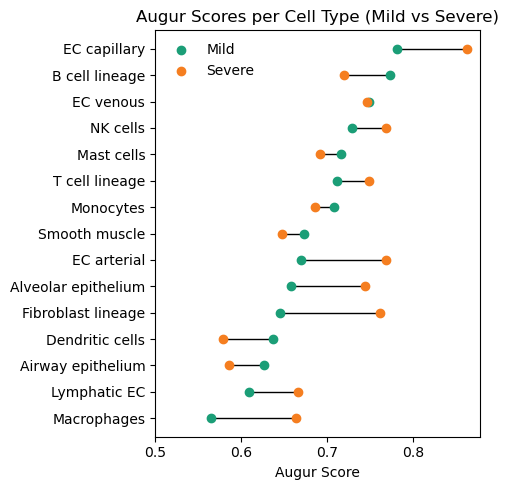

In [6]:
y_pos = np.arange(len(df))

palette = {
    "Mild": "#1B9E77",
    "Severe": "#F57E20"
}

plt.figure(figsize=(5, 5))

for i, row in df.iterrows():
    mild = row["mean_augur_score_mild"]
    severe = row["mean_augur_score_severe"]

    # Connecting line (always left to right)
    plt.hlines(y=i, xmin=min(mild, severe), xmax=max(mild, severe), color="black", linewidth=1)

    # Mild / Severe points
    plt.plot(mild, i, 'o', color=palette["Mild"], markersize=6)
    plt.plot(severe, i, 'o', color=palette["Severe"], markersize=6)

plt.yticks(y_pos, df["cell_type"])
plt.xlabel("Augur Score")
plt.title("Augur Scores per Cell Type (Mild vs Severe)")
plt.xlim(left=0.5)

plt.scatter([], [], color=palette["Mild"], label="Mild")
plt.scatter([], [], color=palette["Severe"], label="Severe")
plt.legend(frameon=False)

plt.tight_layout()
#plt.savefig(plot_folder + "Augur_level_2.pdf", bbox_inches="tight")
plt.show()